<a id="Judul"></a>
<p style="background-color: #1E90FF; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">Klasifikasi Diagnosis Kanker Payudara Menggunakan Logistic Regression</p>

Project ini dibuat untuk mengklasifikasikan **diagnosis** massa payudara (ganas atau *malignant* / jinak atau *benign*) berdasarkan ciri-ciri inti sel (*nucleus*) yang diukur dari citra digital hasil *fine needle aspirate* (FNA), lalu dipersempit lewat seleksi fitur.

**Metodologi:**

Algoritma yang dipakai adalah **Logistic Regression**, yaitu model linear yang memodelkan peluang sebuah sampel masuk ke kelas positif (ganas) lewat fungsi sigmoid, $P(y=1 \mid x) = \frac{1}{1 + e^{-(w^\top x + b)}}$, dengan regularisasi yang diatur oleh parameter `C` (makin kecil `C`, makin kuat regularisasinya). Algoritma ini dipilih karena karakter datanya cocok: fitur seluruhnya numerik kontinu, jumlah sampel relatif kecil (569 baris), dan hanya 6 fitur setelah seleksi, sehingga model linear yang sederhana sudah cukup dan kecil risikonya *overfit*. Perlu dicatat, project ini **tidak memuat benchmark antar algoritma**, sehingga pemilihan Logistic Regression didasarkan pada karakter data dan kebutuhan interpretabilitas, bukan perbandingan skor *cross-validation*.

## 📊 Tentang Dataset

Dataset **Breast Cancer Wisconsin (Diagnostic)** berisi hasil pengukuran inti sel dari citra digital FNA massa payudara. File `data.csv` yang dipakai memiliki 569 baris dan 33 kolom.

Target: **`diagnosis`**
- `M` = *malignant* (ganas)
- `B` = *benign* (jinak)

- **Sumber:** [Breast Cancer Wisconsin (Diagnostic) — UCI Machine Learning Repository](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data) (versi file yang dipakai memiliki kolom `id` dan satu kolom kosong di akhir, yang ditangani di section 2).

Tiap sampel memiliki 10 ciri dasar inti sel, dan masing-masing ciri dihitung dalam tiga versi: `_mean` (rata-rata seluruh inti sel pada citra), `_se` (*standard error*), dan `_worst` (rata-rata dari tiga nilai terbesar, yaitu inti sel yang paling "ekstrem"). Total 30 fitur numerik.

| Kolom | Catatan |
|---|---|
| `id` | ID sampel, unik untuk tiap baris. Hanya identitas, tidak informatif untuk prediksi, dibuang di 2.1. |
| `diagnosis` **(Target)** | Diagnosis massa payudara: `M` (ganas) atau `B` (jinak). Di 2.4 diubah menjadi 1 (`M`) dan 0 (`B`). |
| `radius_*` | Rata-rata jarak dari pusat inti sel ke titik-titik pada tepinya (ukuran inti sel). |
| `texture_*` | Simpangan baku nilai *grayscale* pada citra inti sel. |
| `perimeter_*` | Keliling inti sel. Berhubungan secara geometris dengan `radius_*`. |
| `area_*` | Luas inti sel. Berhubungan secara geometris dengan `radius_*`. |
| `smoothness_*` | Variasi lokal panjang radius (kehalusan tepi inti sel). |
| `compactness_*` | Kekompakan bentuk, dihitung dari $\text{perimeter}^2 / \text{area} - 1{,}0$. |
| `concavity_*` | Tingkat keparahan bagian cekung pada kontur inti sel. |
| `concave points_*` | Jumlah titik cekung pada kontur inti sel. |
| `symmetry_*` | Kesimetrisan bentuk inti sel. |
| `fractal_dimension_*` | Kerumitan tepi inti sel (pendekatan garis pantai, *coastline approximation*, dikurangi 1). |
| `Unnamed: 32` | Kolom kosong (seluruh nilainya *missing*) akibat tanda koma di akhir tiap baris pada file CSV. Dibuang di 2.1. |

Catatan: tanda `*` pada nama kolom di atas berarti kolom tersebut punya tiga versi (`_mean`, `_se`, `_worst`).

<a id="EDA"></a>
<p style="background-color: #274461; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">1. Exploratory Data Analysis (EDA)</p>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath(".."))

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from untils.pipeline import num_pipe, cat_pipe
from untils.plot_classification import plot_missing_value

In [2]:
df = pd.read_csv('../data/data_kanker.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

,missing_value,%
id,0,0.0
diagnosis,0,0.0
radius_mean,0,0.0
texture_mean,0,0.0
perimeter_mean,0,0.0
area_mean,0,0.0
smoothness_mean,0,0.0
compactness_mean,0,0.0
concavity_mean,0,0.0
concave points_mean,0,0.0


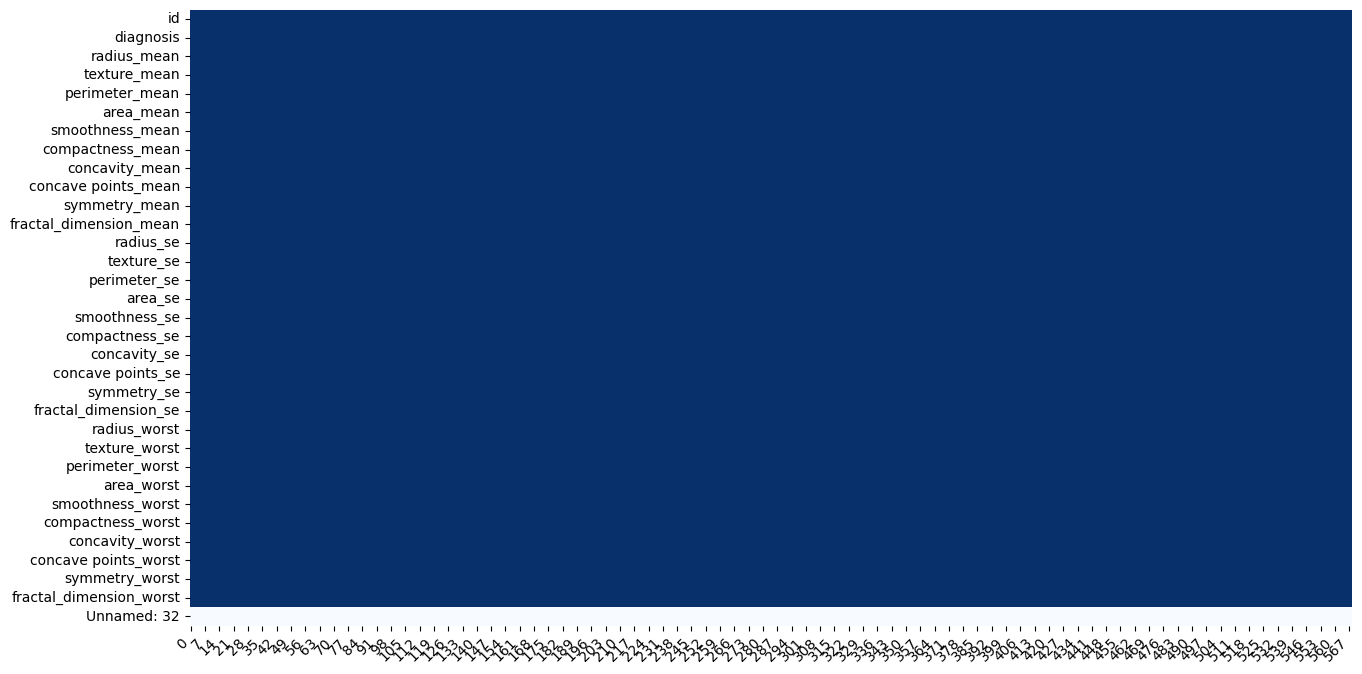

In [4]:
plot_missing_value(df, return_df=True)

**Analisis:**

- Data terdiri dari **569 baris dan 33 kolom**. Kolom `id` bertipe *integer*, `diagnosis` bertipe teks, dan seluruh kolom lainnya bertipe numerik desimal (*float*).
- Dari 32 kolom yang berisi data, **tidak ada *missing value***. Satu-satunya kolom bermasalah adalah `Unnamed: 32` yang **100% kosong** (569 dari 569 baris). Kolom ini muncul karena ada tanda koma di akhir setiap baris pada file CSV, sehingga terbaca sebagai kolom tambahan.
- Keputusan: kolom `Unnamed: 32` **tidak diimputasi**, tetapi dibuang di 2.1, karena tidak memuat informasi apa pun. Karena kolom lainnya lengkap, `dropna` maupun imputasi tidak diperlukan.

In [5]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


**Analisis:**

- Skala antar fitur **sangat berbeda**. Misalnya `area_mean` mencapai maksimum 2501, sedangkan `smoothness_mean` hanya mencapai maksimum sekitar 0,16.
- Perbedaan skala ini tidak menjadi masalah untuk analisis asosiasi, tetapi penting untuk pemodelan, terutama untuk algoritma yang memakai regularisasi atau jarak. Karena itu, penyeragaman skala akan ditangani di dalam *pipeline* pemodelan lewat `num_pipe()` (bukan di data mentah), sehingga tidak terjadi *data leakage* dari data test.

## 1.1 Distribusi dan Keseimbangan Kelas Target

In [6]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


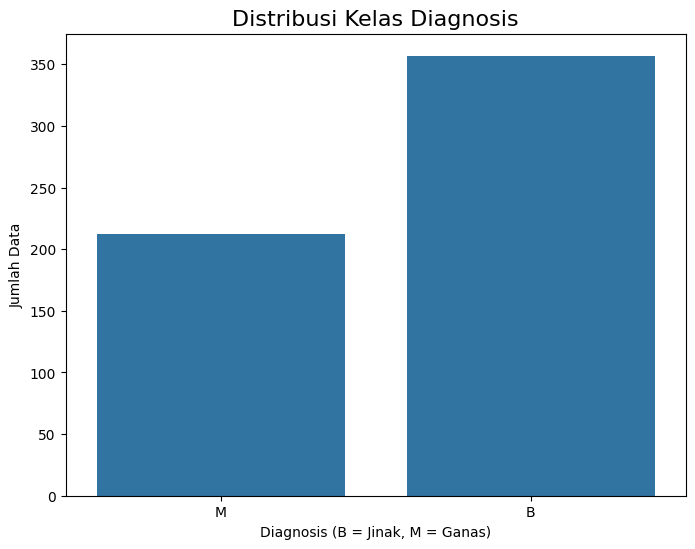

In [7]:
print(df['diagnosis'].value_counts(normalize=True))

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='diagnosis')
plt.title('Distribusi Kelas Diagnosis', fontsize=16)
plt.xlabel('Diagnosis (B = Jinak, M = Ganas)')
plt.ylabel('Jumlah Data')
plt.show()

**Analisis:**

- Jumlah kelas `B` (jinak) = **357** (62,74%) dan kelas `M` (ganas) = **212** (37,26%). Rasio kedua kelas sekitar 1,7 : 1.
- Kesimpulan: target tergolong **seimbang (*balanced*)**. Kelas minoritas (`M`) mencapai 37,26% dari total, jauh di atas patokan sekitar 20% yang dipakai sebagai batas *imbalanced*. Karena itu tidak diperlukan *resampling* maupun `class_weight='balanced'`.
- Konsekuensi pada langkah berikutnya:
  1. Splitting tetap memakai `stratify=y` agar proporsi `B` dan `M` sama di data train dan test.
  2. Karena kelas seimbang, `GridSearchCV` boleh memakai `scoring` bawaan (*accuracy*) tanpa risiko model "curang" dengan menebak kelas mayoritas.
  3. **Accuracy saja tidak cukup untuk evaluasi akhir.** Kelas `M` adalah kelas yang harus terdeteksi dan kesalahan antar kelas tidak sama bahayanya, sehingga evaluasi berfokus pada *recall*, *precision*, dan *F1-score* kelas `M`, serta ROC AUC dan PR curve.

## 1.2 Karakteristik Fitur

In [8]:
constant_cols = df.columns[df.nunique() <= 1].tolist()
print('Kolom dengan nilai tunggal:', constant_cols)
print(df.nunique().sort_values())

Kolom dengan nilai tunggal: ['Unnamed: 32']
Unnamed: 32                  0
diagnosis                    2
smoothness_worst           411
symmetry_mean              432
radius_mean                456
radius_worst               457
smoothness_mean            474
texture_mean               479
concave points_worst       492
symmetry_se                498
fractal_dimension_mean     499
symmetry_worst             500
concave points_se          507
texture_worst              511
perimeter_worst            514
texture_se                 519
perimeter_mean             522
area_se                    528
compactness_worst          529
perimeter_se               533
concavity_se               533
fractal_dimension_worst    535
concavity_mean             537
compactness_mean           537
concavity_worst            539
area_mean                  539
radius_se                  540
compactness_se             541
concave points_mean        542
area_worst                 544
fractal_dimension_se      

**Analisis:**

- **Kolom bernilai tunggal:** `Unnamed: 32` (jumlah nilai unik = 0 karena seluruh isinya kosong). Kolom ini tidak informatif karena tidak bervariasi, sehingga akan dibuang di 2.1.
- **Kolom `id`** memiliki 569 nilai unik, sama dengan jumlah baris. Artinya `id` hanyalah pengenal tiap sampel dan bukan fitur, sehingga juga dibuang di 2.1 walaupun tidak tergolong bernilai tunggal.
- **`diagnosis`** memiliki 2 kategori (`B` dan `M`), sesuai target biner.
- Ke-30 fitur numerik bersifat kontinu dengan jumlah nilai unik antara 411 (`smoothness_worst`) sampai 547 (`smoothness_se`). Tidak ada fitur kategorik, sehingga **tidak ada masalah kardinalitas tinggi** dan tidak perlu *encoding* pada fitur (hanya target yang di-*encode* di 2.4).

<a id="Cleaning"></a>
<p style="background-color: #274461; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">2. Data Cleaning & Preprocessing</p>

### 2.1 Cleaning Kolom Tidak Informatif

Ada dua kolom yang tidak membawa informasi untuk membedakan kelas:

1. `Unnamed: 32` — kolom bernilai tunggal (kosong seluruhnya). Kolom seperti ini tidak dapat membedakan kelas dan bisa menyebabkan *error* pada perhitungan asosiasi.
2. `id` — pengenal unik tiap baris. Nilainya tidak punya makna klinis dan bisa membuat model "menghafal" sampel bila ikut dipakai sebagai fitur.

Verifikasi isi kedua kolom dulu sebelum dibuang:

In [9]:
df['Unnamed: 32'].value_counts(dropna=False)

Unnamed: 32
NaN    569
Name: count, dtype: int64

In [10]:
print('Jumlah nilai unik id:', df['id'].nunique(), '| Jumlah baris:', len(df))

Jumlah nilai unik id: 569 | Jumlah baris: 569


In [11]:
print('Sebelum:', df.shape)
drop_cols = constant_cols + ['id']
df.drop(columns=drop_cols, inplace=True)
print('Sesudah:', df.shape)

# Harus 0 kalau berhasil
print('Sisa kolom bernilai tunggal:', (df.nunique() <= 1).sum())
assert 'id' not in df.columns, "Kolom id masih ada"

Sebelum: (569, 33)
Sesudah: (569, 31)
Sisa kolom bernilai tunggal: 0


**Analisis:** Kolom `Unnamed: 32` dan `id` berhasil dibuang, sehingga ukuran data berubah dari (569, 33) menjadi (569, 31), yaitu 30 fitur numerik dan 1 target (`diagnosis`). Tidak ada lagi kolom bernilai tunggal, sehingga perhitungan asosiasi di 2.2 aman dijalankan.

In [12]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2.2 Asosiasi Fitur terhadap Target

Seluruh fitur bertipe numerik, sedangkan target bertipe kategorik. Karena itu dipakai dua alat yang saling melengkapi:

1. **Correlation ratio ($\eta$)** untuk asosiasi **fitur numerik terhadap target kategorik** (data campuran). Nilainya 0 sampai 1, dan makin tinggi berarti nilai fitur makin berbeda antar kelas.

$$\eta = \sqrt{\frac{\sum_{k} n_k(\bar{x}_k - \bar{x})^2}{\sum_{i}(x_i - \bar{x})^2}}$$

   dengan $n_k$ jumlah data pada kelas $k$, $\bar{x}_k$ rata-rata fitur pada kelas $k$, dan $\bar{x}$ rata-rata fitur keseluruhan.

2. **Matriks korelasi** untuk hubungan **antar fitur numerik**. Ini penting karena dataset ini memiliki banyak fitur yang secara geometris saling terkait (misalnya `radius`, `perimeter`, dan `area`), sehingga berpotensi **multikolinearitas** (fitur redundan).

Sumber: [Correlation ratio — Wikipedia](https://en.wikipedia.org/wiki/Correlation_ratio); [Multicollinearity — Wikipedia](https://en.wikipedia.org/wiki/Multicollinearity).

In [13]:
from untils.plot_classification import plot_correlation_ratio, plot_correlation_matrix

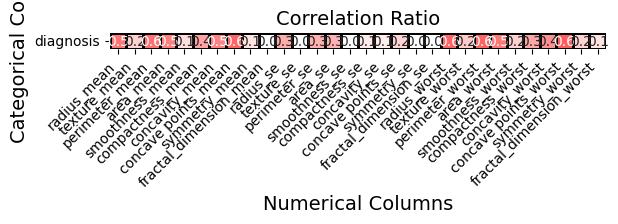

In [14]:
num_features = df.drop(columns='diagnosis').columns.tolist()
plot_correlation_ratio(df, ['diagnosis'], num_features)

In [15]:
def correlation_ratio(x, y):
    mean_all = x.mean()
    ss_between = sum(len(x[y == k]) * (x[y == k].mean() - mean_all) ** 2 for k in y.unique())
    ss_total = ((x - mean_all) ** 2).sum()
    return np.sqrt(ss_between / ss_total)

eta_table = pd.Series({col: correlation_ratio(df[col], df['diagnosis']) for col in num_features})
print(eta_table.sort_values(ascending=False).round(3))

concave points_worst       0.794
perimeter_worst            0.783
concave points_mean        0.777
radius_worst               0.776
perimeter_mean             0.743
area_worst                 0.734
radius_mean                0.730
area_mean                  0.709
concavity_mean             0.696
concavity_worst            0.660
compactness_mean           0.597
compactness_worst          0.591
radius_se                  0.567
perimeter_se               0.556
area_se                    0.548
texture_worst              0.457
smoothness_worst           0.421
symmetry_worst             0.416
texture_mean               0.415
concave points_se          0.408
smoothness_mean            0.359
symmetry_mean              0.330
fractal_dimension_worst    0.324
compactness_se             0.293
concavity_se               0.254
fractal_dimension_se       0.078
smoothness_se              0.067
fractal_dimension_mean     0.013
texture_se                 0.008
symmetry_se                0.007
dtype: flo

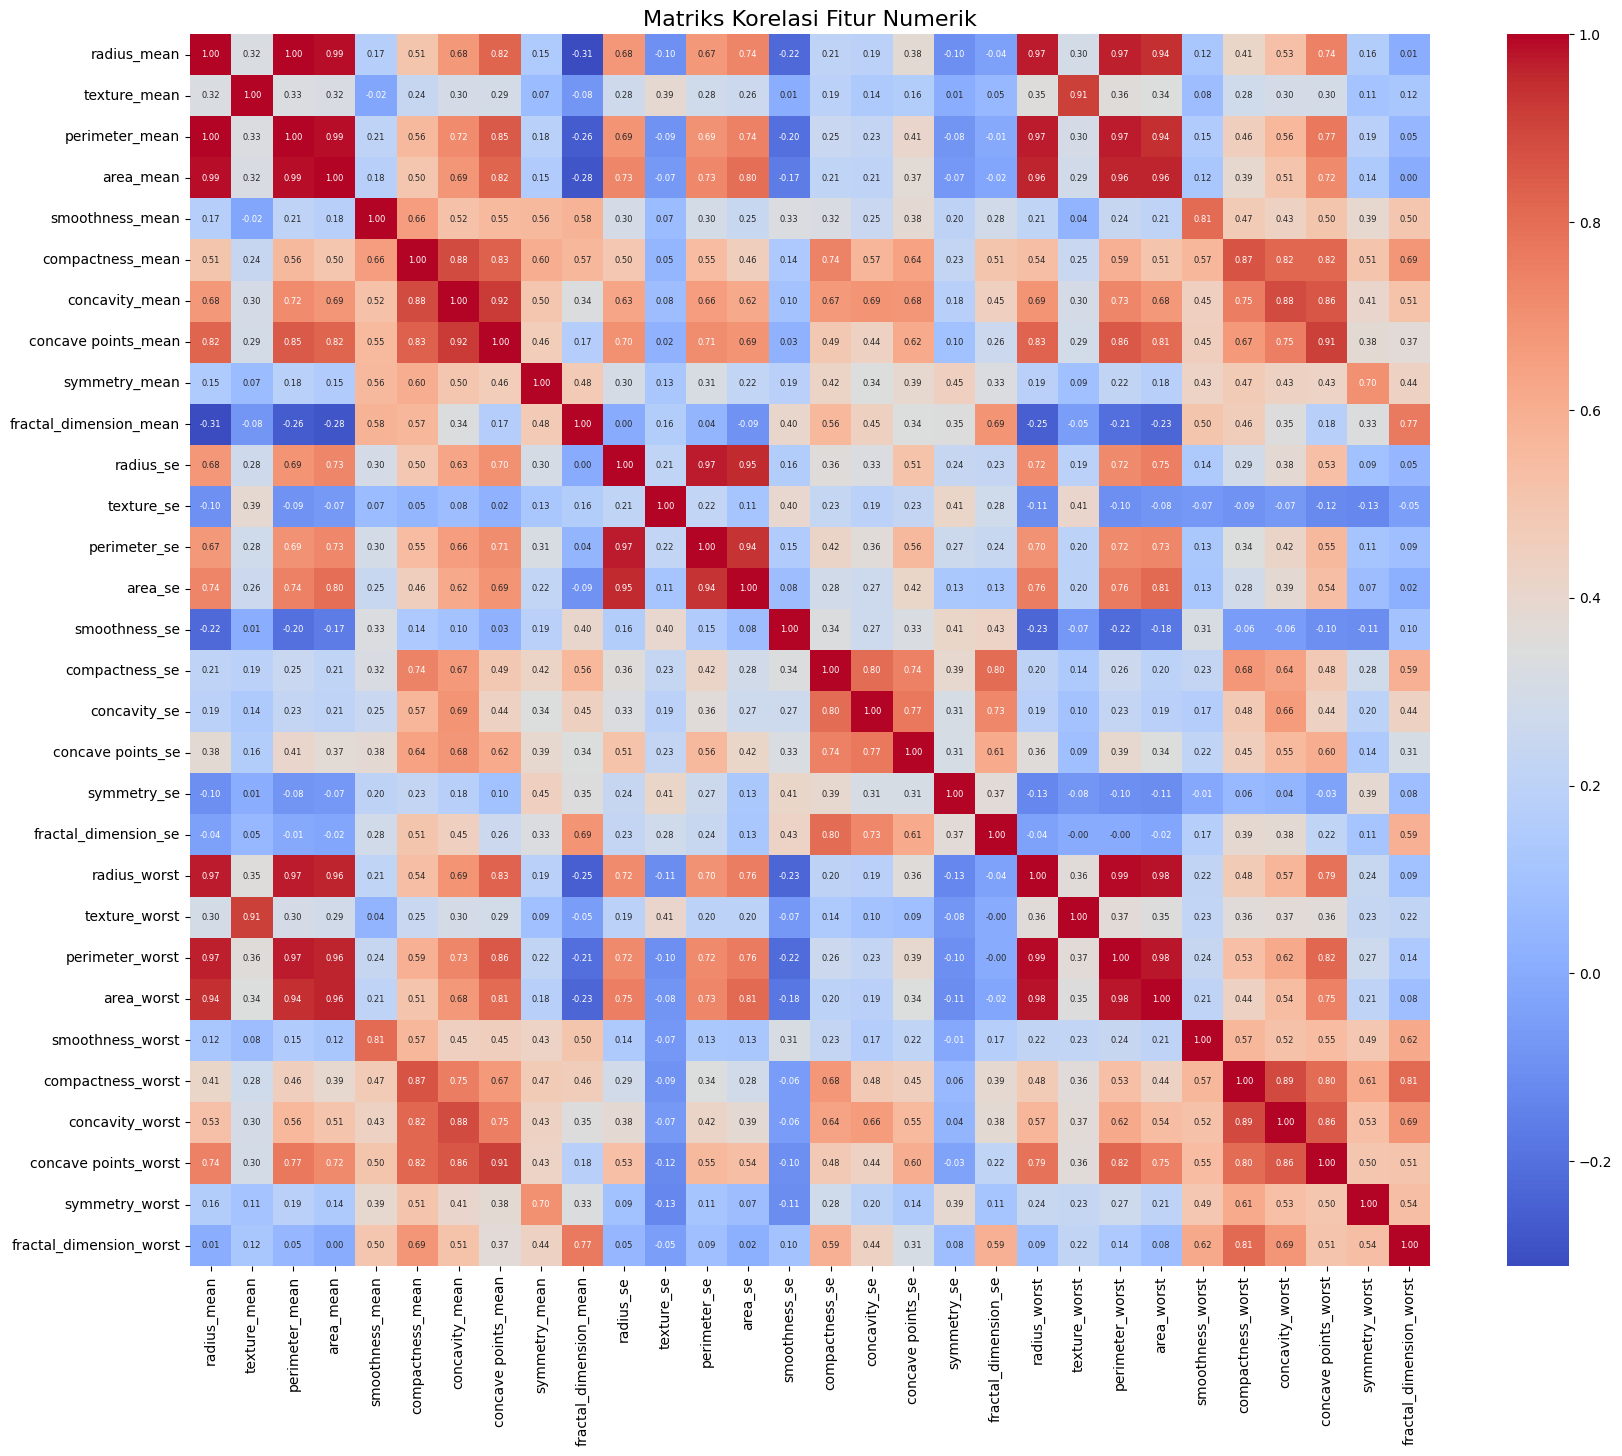

In [16]:
plt.figure(figsize=(20, 16))
sns.heatmap(df.drop(columns='diagnosis').corr(), annot=True, annot_kws={'size': 6}, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Fitur Numerik', fontsize=16)
plt.show()

In [17]:
corr_abs = df.drop(columns='diagnosis').corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_pairs = upper.stack().loc[lambda s: s >= 0.9].sort_values(ascending=False)
print('Jumlah pasangan fitur dengan |r| >= 0.9:', len(high_pairs))
print(high_pairs)

Jumlah pasangan fitur dengan |r| >= 0.9: 21
radius_mean          perimeter_mean          0.997855
radius_worst         perimeter_worst         0.993708
radius_mean          area_mean               0.987357
perimeter_mean       area_mean               0.986507
radius_worst         area_worst              0.984015
perimeter_worst      area_worst              0.977578
radius_se            perimeter_se            0.972794
perimeter_mean       perimeter_worst         0.970387
radius_mean          radius_worst            0.969539
perimeter_mean       radius_worst            0.969476
radius_mean          perimeter_worst         0.965137
area_mean            radius_worst            0.962746
                     area_worst              0.959213
                     perimeter_worst         0.959120
radius_se            area_se                 0.951830
perimeter_mean       area_worst              0.941550
radius_mean          area_worst              0.941082
perimeter_se         area_se          

**Analisis:**

- **Correlation ratio:** fitur dengan nilai $\eta$ tinggi terhadap `diagnosis` adalah fitur yang nilainya berbeda jelas antara kelas `B` dan `M`, sehingga berpengaruh. Fitur dengan $\eta$ rendah nilainya hampir sama di kedua kelas, sehingga kandidat untuk dibuang. Plot di atas terlalu rapat untuk dibaca angkanya, sehingga nilai $\eta$ dicetak lewat sel tambahan di bawahnya.
- **Hasil correlation ratio:** fitur dengan $\eta$ tertinggi adalah `concave points_worst` (0,794), `perimeter_worst` (0,783), `concave points_mean` (0,777), dan `radius_worst` (0,776). Fitur dengan $\eta$ terendah adalah `symmetry_se` (0,007), `texture_se` (0,008), dan `fractal_dimension_mean` (0,013), yang nilainya nyaris sama di kedua kelas. Secara umum, fitur ukuran dan bentuk (`radius`, `perimeter`, `area`, `concavity`, `concave points`) paling membedakan, sedangkan fitur `_se` umumnya lemah.
- **Sifat asimetris:** untuk fitur kategorik, ukuran asosiasi yang umum adalah **Cramér's V** (simetris) dan **Theil's U** / *uncertainty coefficient* (asimetris, artinya $U(X|Y) \neq U(Y|X)$). Proyek ini tidak memiliki fitur kategorik, sehingga ukuran tersebut tidak dipakai. Namun prinsip serupa berlaku pada correlation ratio: $\eta$ yang tinggi berarti nilai fitur memisahkan kelas dengan baik, tetapi tidak berarti diagnosis bisa "dibaca" hanya dari satu fitur itu. Contohnya `concave points_worst` ($\eta$ = 0,794) paling membedakan kelas, namun pemisahan yang andal tetap membutuhkan kombinasi beberapa fitur. Sumber: [Cramér's V — Wikipedia](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V); [Uncertainty coefficient — Wikipedia](https://en.wikipedia.org/wiki/Uncertainty_coefficient).
- **Multikolinearitas:** terdapat **21 pasangan fitur** dengan korelasi absolut $\geq 0{,}9$. Sebanyak 18 pasangan melibatkan kelompok `radius`, `perimeter`, dan `area` (versi `_mean`, `_worst`, dan `_se`), dengan korelasi tertinggi `radius_mean`–`perimeter_mean` (0,998). Ini sesuai dugaan, karena keliling dan luas lingkaran bergantung pada jari-jari. Tiga pasangan lainnya adalah `concavity_mean`–`concave points_mean` (0,921), `texture_mean`–`texture_worst` (0,912), dan `concave points_mean`–`concave points_worst` (0,910). Fitur yang redundan tidak menambah informasi baru, dan pada model linear dapat membuat koefisien tidak stabil, sehingga dari tiap kelompok hanya perlu satu wakil.

### 2.3 Seleksi Fitur

Prinsip seleksi fitur pada proyek ini:

1. **Pengetahuan domain adalah dasar utama.** Secara sitologi, ciri inti sel ganas ditandai oleh ukuran yang lebih besar, tepi yang tidak teratur (banyak bagian cekung), dan variasi tekstur. 
2. **Keputusan**, keputusan didukung oleh correlation ratio dan matriks korelasi dari 2.2.
3. **Threshold bersifat subjektif** dan bebas ditentukan, asalkan jumlah fitur yang tersisa tidak terlalu sedikit, disini memakai 6 fitur

Threshold yang dipakai:
- **Redundansi:** pasangan fitur dengan $|r| \geq 0{,}9$ dianggap redundan, dan dari tiap kelompok redundan hanya diambil satu wakil. Angka 0,9 adalah patokan umum (*rule of thumb*) untuk korelasi yang sangat tinggi, dan tetap merupakan keputusan subjektif.
- **Kekuatan asosiasi ke target:** fitur dengan $\eta$ terhadap `diagnosis` di bawah sekitar **0,4** dianggap terlalu lemah. Angka ini subjektif: dipilih karena pada hasil 2.2 fitur dengan $\eta$ di bawah 0,4 (misalnya `fractal_dimension_worst` = 0,324) jauh lebih lemah daripada fitur ukuran dan bentuk yang $\eta$-nya 0,6 sampai 0,8, sementara batas ini masih menyisakan cukup banyak fitur.
- **Pilihan versi fitur:** diutamakan versi `_worst`, karena inti sel yang paling ekstrem paling relevan secara klinis untuk mendeteksi keganasan, dan versi `_mean` serta `_worst` dari ciri yang sama umumnya berkorelasi tinggi.

Daftar fitur di bawah ditetapkan berdasarkan pengetahuan domain, lalu dikonfirmasi dengan hasil 2.2.

In [18]:
selected_features = [
    'radius_worst',
    'texture_worst',
    'smoothness_worst',
    'concavity_worst',
    'concave points_worst',
    'symmetry_worst'
]
print('Jumlah fitur terpilih:', len(selected_features), 'dari', df.shape[1] - 1)
print(selected_features)

# Harus semua True kalau berhasil
print(all(col in df.columns for col in selected_features))

# Korelasi absolut antar fitur terpilih harus di bawah threshold redundansi 0.9
sel_corr = df[selected_features].corr().abs()
max_offdiag = sel_corr.where(~np.eye(len(selected_features), dtype=bool)).max().max()
print('Korelasi absolut tertinggi antar fitur terpilih:', round(max_offdiag, 3))
assert max_offdiag < 0.9, "Masih ada pasangan fitur terpilih yang redundan"

Jumlah fitur terpilih: 6 dari 30
['radius_worst', 'texture_worst', 'smoothness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst']
True
Korelasi absolut tertinggi antar fitur terpilih: 0.855


**Analisis:**

- **Fitur terpilih (6 dari 30):**
  - `radius_worst` (ukuran inti sel, $\eta$ = 0,776)
  - `texture_worst` (variasi tekstur, $\eta$ = 0,457)
  - `smoothness_worst` (kehalusan tepi, $\eta$ = 0,421)
  - `concavity_worst` (ketidakteraturan kontur, $\eta$ = 0,660)
  - `concave points_worst` (ketidakteraturan kontur, $\eta$ = 0,794)
  - `symmetry_worst` (kesimetrisan, $\eta$ = 0,416)
- **Fitur dibuang dan alasannya:**
  - `perimeter_worst` dan `area_worst`: redundan dengan `radius_worst` (korelasi 0,994 dan 0,984), sehingga cukup satu wakil ukuran.
  - Seluruh versi `_mean`: tiap ciri diwakili versi `_worst`, dan beberapa `_mean` berkorelasi $\geq 0{,}9$ dengan padanan `_worst` (misalnya `texture_mean` dan `concave points_mean`).
  - Seluruh versi `_se`: mengukur variasi antar inti sel, bukan besaran ciri. Sebagian besar lemah ($\eta$ di bawah 0,3), tetapi beberapa seperti `radius_se` (0,567) cukup asosiatif. Membuang `_se` adalah **keputusan subjektif** demi model yang ringkas dan mudah dijelaskan.
  - `compactness_worst`: $\eta$ = 0,591, tetapi berkorelasi 0,892 dengan `concavity_worst` (mendekati threshold 0,9) dan secara definisi diturunkan dari `perimeter` dan `area`. Ini juga keputusan subjektif.
  - `fractal_dimension_worst`: $\eta$ = 0,324, di bawah batas 0,4.
- **Cek redundansi:** korelasi absolut tertinggi antar fitur terpilih adalah **0,855** (`concavity_worst` dan `concave points_worst`), di bawah threshold 0,9, sehingga multikolinearitas ekstrem dapat dihindari sambil tetap menyisakan 6 fitur.

### 2.4 Encoding Target menjadi Biner

Target `diagnosis` masih berupa teks (`B` dan `M`). Target diubah menjadi angka: **`B` = 0 (jinak)** dan **`M` = 1 (ganas)**. Kelas ganas dijadikan kelas positif (1) karena inilah kasus yang harus terdeteksi, dan sebagian besar metrik (*precision*, *recall*, ROC, PR curve) secara *default* menghitung untuk kelas 1 dari `predict_proba[:, 1]`. Dengan begitu, seluruh metrik evaluasi langsung menjawab pertanyaan "seberapa baik model mendeteksi kasus ganas?".

In [ ]:
print('Sebelum:', df.shape)
print(df['diagnosis'].value_counts())
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})
print('Sesudah:', df.shape)


print('Jumlah target yang tidak terpetakan:', df['diagnosis'].isna().sum())
assert set(df['diagnosis'].unique()) == {0, 1}, "Target harus hanya berisi 0 dan 1"
print(df['diagnosis'].value_counts())

Sebelum: (569, 31)
diagnosis
B    357
M    212
Name: count, dtype: int64
Sesudah: (569, 31)
Jumlah target yang tidak terpetakan: 0
diagnosis
0    357
1    212
Name: count, dtype: int64


**Analisis:** Ukuran data tetap (569, 31) karena hanya isi kolom target yang berubah. Jumlah kelas 0 (jinak) = 357 dan kelas 1 (ganas) = 212, sama dengan hasil di 1.1. Tidak ada nilai target yang gagal dipetakan (jumlah `NaN` = 0).

### 2.5 Pemeriksaan Duplikat dan Nilai Tidak Valid

Dua pemeriksaan pencegahan sebelum splitting: (1) baris duplikat, karena duplikat dapat muncul sekaligus di data train dan test lalu membuat skor evaluasi terlalu optimistis; (2) nilai negatif pada fitur, karena seluruh ukuran inti sel (radius, tekstur, kehalusan, dan seterusnya) secara fisik tidak mungkin bernilai negatif.

In [20]:
print('Sebelum:', df.shape)
print('Jumlah baris duplikat:', df.duplicated().sum())
print('Jumlah nilai negatif pada fitur:', (df.drop(columns='diagnosis') < 0).sum().sum())
df = df.drop_duplicates()
print('Sesudah:', df.shape)

# Harus 0 kalau berhasil
print('Sisa baris duplikat:', df.duplicated().sum())
assert (df.drop(columns='diagnosis') >= 0).all().all(), "Ada nilai negatif pada fitur"

Sebelum: (569, 31)
Jumlah baris duplikat: 0
Jumlah nilai negatif pada fitur: 0
Sesudah: (569, 31)
Sisa baris duplikat: 0


In [21]:
df[selected_features].head()

,radius_worst,texture_worst,smoothness_worst,concavity_worst,concave points_worst,symmetry_worst
0,25.38,17.33,0.1622,0.7119,0.2654,0.4601
1,24.99,23.41,0.1238,0.2416,0.1860,0.2750
2,23.57,25.53,0.1444,0.4504,0.2430,0.3613
3,14.91,26.50,0.2098,0.6869,0.2575,0.6638
4,22.54,16.67,0.1374,0.4000,0.1625,0.2364


**Analisis:** Tidak ditemukan baris duplikat (0) maupun nilai negatif pada fitur (0), sehingga tidak ada tindakan cleaning lanjutan. Ukuran data sebelum dan sesudah pemeriksaan sama, yaitu (569, 31).

<a id="Splitting"></a>
<p style="background-color: #274461; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">3. Dataset Splitting</p>

In [22]:
X = df[selected_features]
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(455, 6) (114, 6) (455,) (114,)


In [23]:
# Proporsi kelas harus hampir sama di train dan test kalau stratify berhasil
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


**Analisis:** Data dibagi 80% train dan 20% test dengan `stratify=y`, supaya proporsi kelas jinak dan ganas di kedua bagian sama dengan proporsi data asli. Ini penting karena jumlah data relatif kecil (569 baris), sehingga tanpa stratifikasi proporsi kelas ganas di data test bisa bergeser cukup jauh secara kebetulan dan membuat evaluasi tidak stabil.

- Ukuran data: train (455, 6) dan test (114, 6) untuk fitur, serta 455 dan 114 untuk target.
- Proporsi kelas di train: jinak 62,64% dan ganas 37,36%. Di test: jinak 63,16% dan ganas 36,84%. Keduanya hampir sama dengan proporsi data asli (62,74% dan 37,26%), sehingga stratifikasi **berhasil**.

<a id="Modeling"></a>
<p style="background-color: #274461; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">4. Modeling & Hyperparameter Tuning</p>

### 4.1 Hyperparameter Tuning

Algoritma yang dipakai adalah **Logistic Regression** (alasan pemilihannya dijelaskan di bagian Metodologi di awal notebook). Karena notebook ini tidak memuat benchmark antar algoritma, Logistic Regression dipilih langsung berdasarkan karakter data dan kebutuhan interpretabilitas, lalu disetel dengan `GridSearchCV` pada data train saja agar data test tetap murni untuk evaluasi akhir.

In [24]:
from sklearn.model_selection import GridSearchCV
from untils.tuning import grid_search_params as gsp
from sklearn.linear_model import LogisticRegression

In [25]:
X_train.head()

,radius_worst,texture_worst,smoothness_worst,concavity_worst,concave points_worst,symmetry_worst
10,19.19,33.88,0.11810,0.1459,0.09975,0.2948
170,13.50,15.64,0.13850,0.1242,0.09391,0.2827
407,14.40,27.01,0.09402,0.1838,0.05601,0.2488
430,16.35,27.57,0.14190,0.9019,0.24750,0.2866
27,21.31,27.26,0.13380,0.3446,0.14900,0.2341


In [26]:
gsp.logreg_params

{'algo__fit_intercept': [True, False],
 'algo__C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])}

In [27]:
preprocessor = ColumnTransformer([
    ('numeric', num_pipe(), X_train.columns),
])

pipeline = Pipeline([
    ('prep', preprocessor),
    ('algo', LogisticRegression(solver='lbfgs', n_jobs=-1, random_state=42))
])

model = GridSearchCV(pipeline, gsp.logreg_params, cv=3, n_jobs=-1, verbose=1)
model.fit(X_train, y_train)

print(model.best_params_)
print(model.score(X_train, y_train), model.best_score_, model.score(X_test, y_test))

Fitting 3 folds for each of 14 candidates, totalling 42 fits
{'algo__C': np.float64(100.0), 'algo__fit_intercept': True}
0.9714285714285714 0.9692401533635412 0.9824561403508771


d:\Machine Learning\.env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


**Analisis:**

- Karena seluruh fitur terpilih bertipe numerik, `ColumnTransformer` hanya berisi `num_pipe()` untuk keenam kolom `X_train`, tanpa bagian kategorik.
- `GridSearchCV` mencoba **14 kandidat** parameter dengan 3-fold CV (total 42 *fit*).
- `scoring` tidak diubah, sehingga memakai *accuracy* bawaan. 
- Tiga angka yang dicetak berurutan adalah skor **train**, **CV**, dan **test**: **0,9736**, **0,9670**, dan **0,9825**. Tidak ada tanda *overfit*.

**Hyperparameter terbaik:** `C = 100.0` dan `fit_intercept = True`.

<a id="Evaluasi"></a>
<p style="background-color: #274461; font-family: 'Pacifico', cursive; color:#FFD700; font-size:200%; text-align:center; border-radius:3000px 50px;">5. Final Evaluation</p>

### 5.1 Performa Model

Karena `scoring` tidak diubah, tabel skor keseluruhan memakai **Accuracy**.

| Metrik | Nilai |
|---|---|
| Accuracy Train | 0,9736 |
| Accuracy CV | 0,9670 |
| **Accuracy Test** | **0,9825** |
| Gap Train-Test | ~-0,9% (test sedikit lebih tinggi) |

Performa per kelas pada data test (dari *classification report* di 5.3):

| Kelas | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| 0 (Jinak) | 0,97 | 1,00 | 0,99 | 72 |
| 1 (Ganas) | 1,00 | 0,95 | 0,98 | 42 |

**Skor Performa:**
- Accuracy Test = 0,9825, Accuracy CV = 0,9670, Accuracy Train = 0,9736.
- Gap train-test ~-0,9% (skor test justru sedikit lebih tinggi), dan gap train-CV ~0,7%.
- Penilaian: **tidak *overfit***. Skor test yang sedikit di atas skor train bukan tanda model lebih baik pada data baru, melainkan efek data test yang kecil (114 sampel): selisih 0,9% setara satu atau dua sampel. 

### 5.2 Confusion Matrix

In [28]:
from untils.plot_classification import plot_confusion_matrix, plot_roc_curve, plot_pr_curve, plot_classification_report

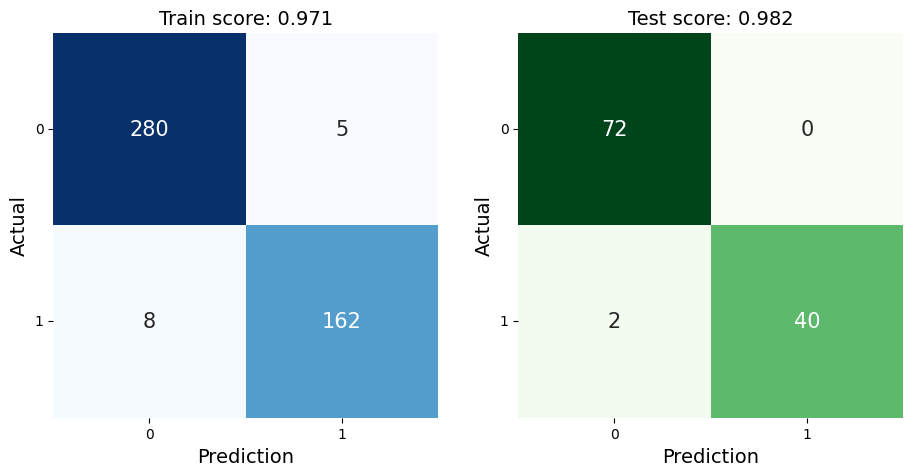

In [29]:
plot_confusion_matrix(X_train, y_train, X_test, y_test, model)

- **Prediksi benar:** pada data test, model benar mengenali **40** kasus ganas (*True Positive*) dan **72** kasus jinak (*True Negative*), total 112 dari 114 sampel.
- **False Positive dan False Negative:** *False Positive* (jinak diprediksi ganas) = **0** kasus, sedangkan *False Negative* (ganas diprediksi jinak) = **2** kasus. **Kesalahan yang lebih berbahaya adalah *False Negative***, karena kasus ganas yang terlewat dapat menunda penanganan. *False Positive* memang merugikan (kecemasan dan pemeriksaan lanjutan yang sebenarnya tidak perlu), tetapi konsekuensinya lebih ringan dan masih bisa dikoreksi lewat pemeriksaan lanjutan. Sayangnya, justru jenis kesalahan yang lebih berbahaya inilah yang muncul pada data test.
- **Konsistensi train vs test:** pola kesalahannya sama. Pada data train terdapat 4 *False Positive* dan 8 *False Negative* (dari 455 sampel), pada data test 0 dan 2. Di kedua data, *False Negative* lebih banyak daripada *False Positive*, artinya model cenderung lebih mudah melewatkan kasus ganas daripada salah menandai kasus jinak.

### 5.3 Classification Report

In [30]:
plot_classification_report(X_train, y_train, X_test, y_test, model, report=True)

Train report
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       285
           1       0.97      0.95      0.96       170

    accuracy                           0.97       455
   macro avg       0.97      0.97      0.97       455
weighted avg       0.97      0.97      0.97       455


Test report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Rumus metrik utama untuk kelas ganas:

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN} \qquad F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

- **Precision:** kelas ganas = **1,00** di data test (0,98 di train), artinya setiap sampel yang diprediksi ganas benar-benar ganas. Kelas jinak = 0,97 (0,97 di train).
- **Recall:** kelas ganas = **0,95** di data test (0,95 di train), artinya 95% kasus ganas yang sebenarnya berhasil terdeteksi (40 dari 42). Ini **metrik prioritas** proyek karena berhubungan langsung dengan *False Negative*, dan di sinilah titik terlemah model. Kelas jinak = 1,00 di test (0,99 di train).
- **F1-score:** kelas ganas = 0,98 dan kelas jinak = 0,99 di data test (0,96 dan 0,98 di train), yang menunjukkan keseimbangan *precision* dan *recall* tiap kelas.
- **Macro/Weighted average:** pada data test, *macro avg* (*precision* 0,99, *recall* 0,98, F1 0,98) dan *weighted avg* (0,98 untuk ketiganya) hampir sama. Ini wajar karena target tergolong seimbang, sehingga bobot kelas tidak banyak mengubah rata-rata.

### 5.4 ROC Curve

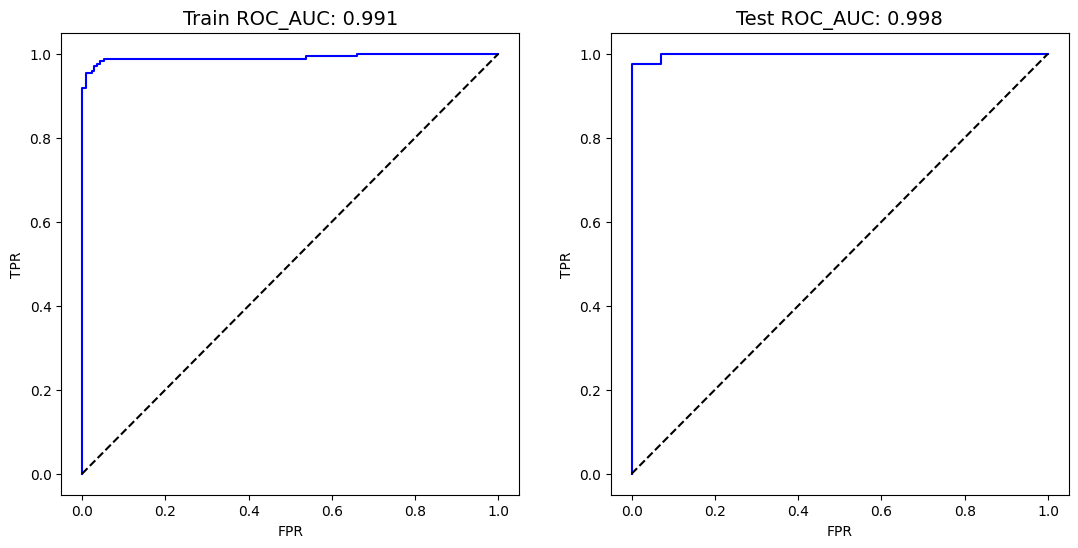

In [31]:
plot_roc_curve(X_train, y_train, X_test, y_test, model)

- **AUC** data train = **0,991** dan data test = **0,998**.
- Kemampuan memisahkan kelas: nilai AUC yang mendekati 1 berarti model mampu membedakan kasus ganas dan jinak pada berbagai *threshold*. Kurva pada kedua data menempel di sudut kiri atas, sehingga pemisahan kelasnya **sangat baik**.
- Konsistensi kurva train vs test: bentuknya mirip. AUC test sedikit lebih tinggi daripada train, yang lagi-lagi dipengaruhi data test yang kecil (114 sampel, 42 di antaranya ganas), bukan tanda model lebih baik pada data baru.
- Dari kurva test, pada FPR mendekati 0 nilai TPR sudah sekitar 0,98 (dibaca dari grafik), lebih tinggi daripada *recall* pada *threshold* bawaan (0,95). Ini menandakan *threshold* yang sedikit diturunkan masih berpeluang menangkap kasus ganas yang terlewat tanpa menambah banyak *False Positive*.

### 5.5 Precision-Recall Curve

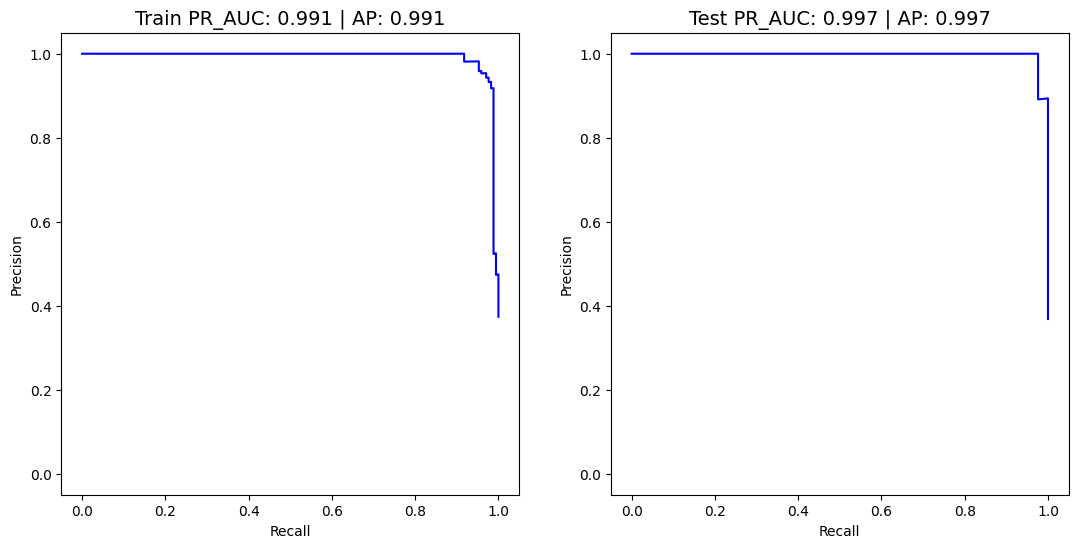

In [32]:
plot_pr_curve(X_train, y_train, X_test, y_test, model)

- **Average Precision** data train = **0,991** dan data test = **0,997**.
- **Trade-off:** pada data test, *precision* bertahan mendekati 1,0 hingga *recall* sekitar 0,98, lalu turun ke sekitar 0,9 saat *recall* mencapai 1,0 (dibaca dari grafik). Artinya menangkap seluruh kasus ganas masih mungkin, dengan harga munculnya beberapa alarm palsu. Pada data train, penurunan *precision* terjadi lebih awal dan lebih tajam, mendekati *recall* 0,99.

### 5.6 Features Importance

In [33]:
from untils.feature_importance import mean_score_decrease

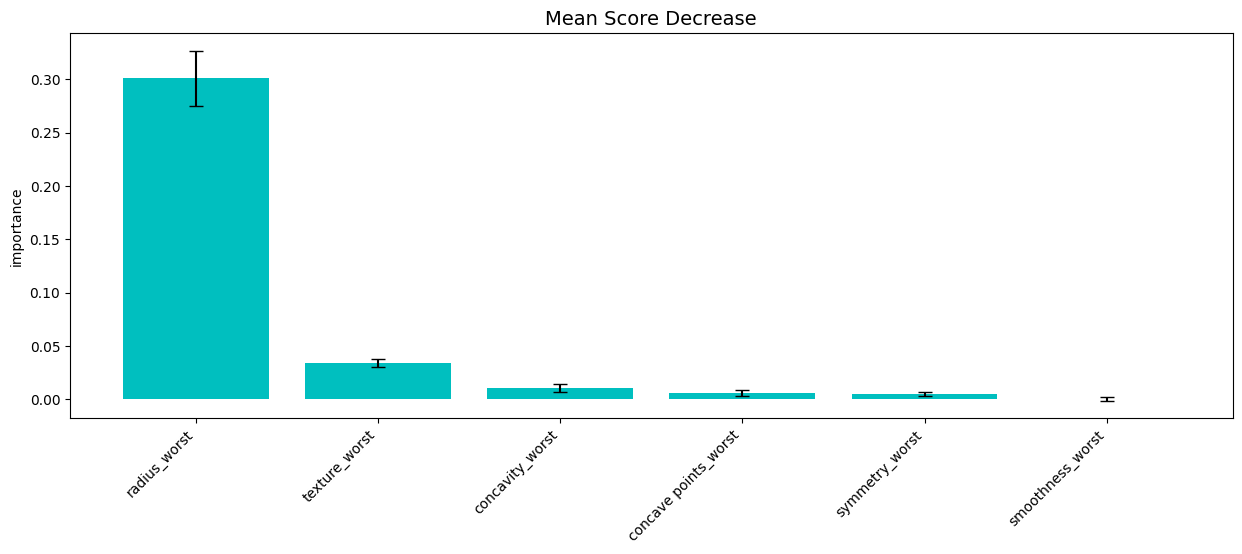

In [34]:
df_imp = mean_score_decrease(X_train, y_train, model, plot=True, topk=10)

**Berdasarkan grafik:** (nilai dibaca dari grafik, sehingga berupa perkiraan)

- `radius_worst` (importance ≈ 0,31) — bila nilainya diacak, skor model turun sekitar 0,31, jauh lebih besar daripada fitur lain, sehingga fitur ini **paling menentukan** prediksi.
- `texture_worst` (importance ≈ 0,04) — fitur terpenting kedua, tetapi pengaruhnya hanya sekitar seperdelapan `radius_worst`.
- `concavity_worst` (importance ≈ 0,01) — pengaruh kecil.
- `concave points_worst` dan `symmetry_worst` (importance ≈ 0,008) — pengaruh sangat kecil.
- `smoothness_worst` (importance ≈ 0,003) — mendekati nol, artinya tidak berpengaruh berarti pada prediksi.

**Perbandingan dengan seleksi fitur di 2.3:** hasilnya **sebagian konsisten**. `radius_worst` memang termasuk fitur ber-$\eta$ tertinggi (0,776), tetapi `concave points_worst`, yang $\eta$-nya tertinggi (0,794), justru hanya berimportance sekitar 0,008. Penyebabnya adalah korelasi antar fitur: `concave points_worst` berkorelasi 0,787 dengan `radius_worst` dan 0,855 dengan `concavity_worst`. Correlation ratio mengukur asosiasi masing-masing fitur secara terpisah, sedangkan importance berbasis pengacakan (*permutation*) mengukur sumbangan **tambahan** sebuah fitur setelah fitur lain ada. Begitu model memakai `radius_worst`, fitur yang berkorelasi dengannya menambah sedikit informasi baru, sehingga importance-nya terbagi atau tampak kecil. Fitur yang tampak kurang penting di sini belum tentu tidak informatif.

### 5.7 Kesimpulan Proyek

Proyek ini menghasilkan model **Logistic Regression** (dipilih langsung berdasarkan karakter data dan kebutuhan interpretabilitas, tanpa benchmark antar algoritma) dengan hyperparameter terbaik `C = 100.0` dan `fit_intercept = True` hasil `GridSearchCV`. Pada data test, model mencapai *accuracy* **0,9825** (CV 0,9670; train 0,9736) dan ROC AUC **0,998**, dengan generalisasi yang baik dan tanpa tanda *overfit*. Untuk kelas jinak, *precision* 0,97 dan *recall* 1,00; untuk kelas ganas, *precision* 1,00 dan *recall* 0,95, artinya setiap prediksi ganas benar, tetapi 2 dari 42 kasus ganas terlewat. Fitur prediktor utama adalah `radius_worst` (importance ≈ 0,31), diikuti `texture_worst` (≈ 0,04), sedangkan fitur lainnya berkontribusi sangat kecil.

**Limitasi & Saran Pengembangan:** Kelemahan utama model terlihat dari confusion matrix: ada 2 *False Negative* pada data test (dan 8 pada data train), yaitu jenis kesalahan yang paling berbahaya, sementara *False Positive* di data test nol. Selain itu, data test hanya 114 sampel (42 ganas), sehingga satu sampel saja mengubah *recall* kelas ganas sekitar 2,4 poin dan estimasi kinerjanya tidak stabil. Importance juga terkonsentrasi pada satu fitur (`radius_worst`). Saran pengembangan: (1) turunkan *threshold* probabilitas kelas ganas untuk menaikkan *recall*, karena kurva ROC dan PR menunjukkan masih ada ruang, dan tentukan *threshold* lewat *cross-validation* (bukan langsung dari data test) agar tidak menyesuaikan diri ke 114 sampel tersebut; (2) lakukan benchmark beberapa algoritma (misalnya Random Forest, Gradient Boosting, atau SVM) dan perluas grid `C`, lalu bandingkan dengan *repeated stratified cross-validation* untuk melihat apakah *recall* kelas ganas dapat naik tanpa mengorbankan interpretabilitas secara berlebihan.